# Geo-FNO style mapping view: physical `u(x)` and latent `u(ξ)`

This notebook:
- loads one sample (default `sample_000000`)
- computes computational coordinates `ξ = IPHI(x, code)`
- plots **physical field** on the irregular mesh
- plots the same field on a **regular latent grid** (`u(ξ)`)

Note: The latent interpolation uses scattered interpolation (`scipy.interpolate.griddata`)
instead of mapped-triangle interpolation, which avoids `Triangulation is invalid` errors
when the mapped mesh connectivity is not a valid planar triangulation.


In [13]:
import h5py
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import torch
from scipy.interpolate import griddata


In [14]:
# ----------- CONFIG -----------
H5_PATH = "/scratch/mnhagen/datasets/incompressible_euler/train.h5"
SAMPLE_ID = "sample_000000"
IPHI_CKPT = "/scratch/mnhagen/models/geofno/cylinder_vel_t0_t-1_1sample_rift_iphi.pt"

# Field selection
T_IDX = -1              # time index in vel[T, N, 2]
FIELD_MODE = "ux"     # one of: 'ux', 'uy', 'speed'

# Geometry code extraction
BOUNDARY_LABEL = 6
BAND_FRAC = 0.06

# Regular latent grid resolution for u(xi)
XI_NX = 260
XI_NY = 140

# Optional clipping to reduce extreme outlier stretch in xi
XI_CLIP_Q_LO = 0.001
XI_CLIP_Q_HI = 0.999

CMAP = "viridis"
# ------------------------------


In [15]:
def fit_circle_kasa(x: np.ndarray, y: np.ndarray):
    A = np.stack([x, y, np.ones_like(x)], axis=1)
    b = -(x**2 + y**2)
    sol, *_ = np.linalg.lstsq(A, b, rcond=None)
    a, b_, c = sol
    xc = -a / 2.0
    yc = -b_ / 2.0
    r2 = (a * a + b_ * b_) / 4.0 - c
    r = float(np.sqrt(max(r2, 0.0)))
    return float(xc), float(yc), float(r)


def estimate_cylinder_from_label6(pos: np.ndarray, node_type: np.ndarray, boundary_label: int = 6, band_frac: float = 0.06):
    xy = pos[node_type == boundary_label]
    if xy.shape[0] < 3:
        raise ValueError(f"Not enough points with node_type == {boundary_label} to fit cylinder.")

    y = xy[:, 1]
    ymin, ymax = float(y.min()), float(y.max())
    band = band_frac * (ymax - ymin)
    cyl_mask = (y > ymin + band) & (y < ymax - band)
    xy_cyl = xy[cyl_mask]

    if xy_cyl.shape[0] < 3:
        xy_cyl = xy

    return fit_circle_kasa(xy_cyl[:, 0], xy_cyl[:, 1])


def load_sample(h5_path: str, sample_id: str):
    with h5py.File(h5_path, "r") as f:
        if sample_id not in f:
            keys = sorted(k for k in f.keys() if k.startswith("sample_"))
            raise KeyError(f"Sample '{sample_id}' not found. Example keys: {keys[:5]}")

        g = f[sample_id]
        pos = g["pos"][:]
        cells = g["cells"][:]
        node_type = g["node_type"][:]
        vel = g["vel"][:]

    return pos, cells, node_type, vel


def select_field(vel: np.ndarray, t_idx: int, mode: str) -> np.ndarray:
    if mode == "ux":
        return vel[t_idx, :, 0].astype(np.float32)
    if mode == "uy":
        return vel[t_idx, :, 1].astype(np.float32)
    if mode == "speed":
        return np.linalg.norm(vel[t_idx], axis=1).astype(np.float32)
    raise ValueError("FIELD_MODE must be one of: 'ux', 'uy', 'speed'")


In [16]:
from geo_FNO_def import IPHI

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

pos, cells, node_type, vel = load_sample(H5_PATH, SAMPLE_ID)
field = select_field(vel, T_IDX, FIELD_MODE)

xc, yc, r = estimate_cylinder_from_label6(pos, node_type, boundary_label=BOUNDARY_LABEL, band_frac=BAND_FRAC)
code42 = np.zeros((42,), dtype=np.float32)
code42[0], code42[1], code42[2] = xc, yc, r

iphi = IPHI(width=32, device=str(device)).to(device)
iphi.load_state_dict(torch.load(IPHI_CKPT, map_location=device))
iphi.eval()

pos_t = torch.from_numpy(pos.astype(np.float32)).unsqueeze(0).to(device)
code_t = torch.from_numpy(code42).unsqueeze(0).to(device)
with torch.no_grad():
    xi_t = iphi(pos_t, code=code_t)
xi = xi_t[0].cpu().numpy()

tri_phys = mtri.Triangulation(pos[:, 0], pos[:, 1], cells)

# Build regular xi-grid
xi1_min, xi1_max = np.quantile(xi[:, 0], [XI_CLIP_Q_LO, XI_CLIP_Q_HI])
xi2_min, xi2_max = np.quantile(xi[:, 1], [XI_CLIP_Q_LO, XI_CLIP_Q_HI])
XI1, XI2 = np.meshgrid(
    np.linspace(float(xi1_min), float(xi1_max), XI_NX),
    np.linspace(float(xi2_min), float(xi2_max), XI_NY),
    indexing="xy",
)

# Robust scattered interpolation in xi-space (no triangulation validity requirement)
U_xi_lin = griddata(points=xi, values=field, xi=(XI1, XI2), method="linear")
U_xi_near = griddata(points=xi, values=field, xi=(XI1, XI2), method="nearest")
U_xi = np.where(np.isnan(U_xi_lin), U_xi_near, U_xi_lin)

vmin = float(np.nanmin(field))
vmax = float(np.nanmax(field))
print(f"Sample {SAMPLE_ID} | field={FIELD_MODE} @ t={T_IDX}")
print(f"Cylinder code: center=({xc:.4f}, {yc:.4f}), r={r:.4f}")
print(f"xi range: [{xi[:,0].min():.4f}, {xi[:,0].max():.4f}] x [{xi[:,1].min():.4f}, {xi[:,1].max():.4f}]")


Device: cuda:0
Sample sample_000000 | field=ux @ t=-1
Cylinder code: center=(0.3436, 0.1245), r=0.0515
xi range: [0.0000, 1.7900] x [0.0000, 0.4108]


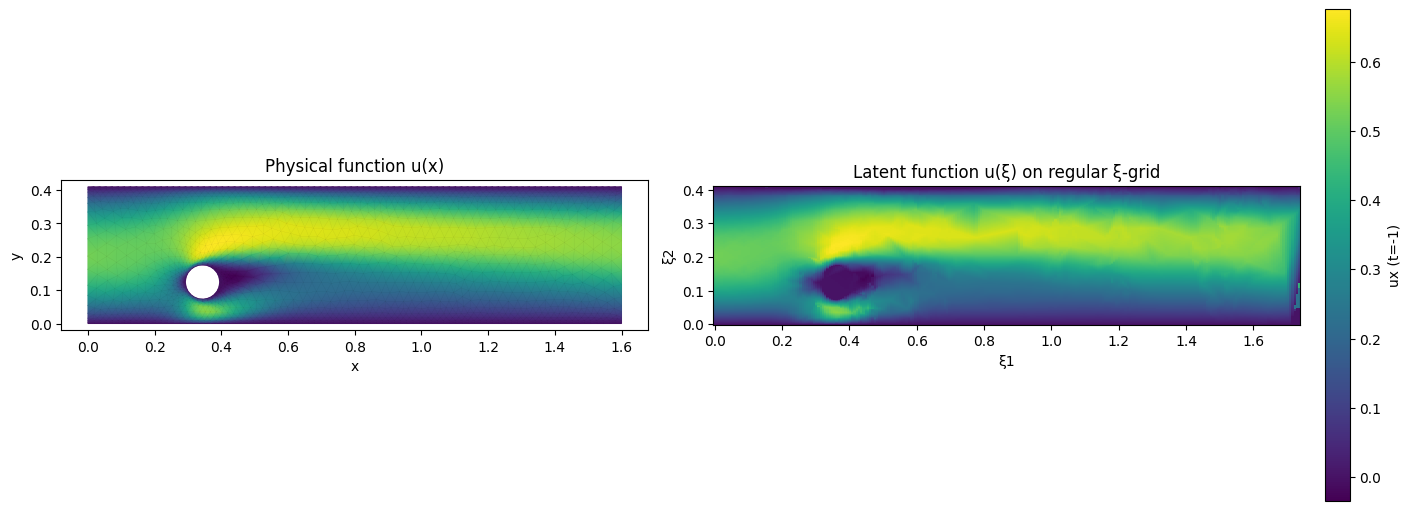

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Physical function u(x) on the irregular mesh
im0 = axes[0].tripcolor(tri_phys, field, shading="gouraud", cmap=CMAP, vmin=vmin, vmax=vmax)
axes[0].triplot(tri_phys, lw=0.12, color="k", alpha=0.14)
axes[0].set_aspect("equal")
axes[0].set_title("Physical function u(x)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# Latent/computational function u(xi) on a regular grid
im1 = axes[1].pcolormesh(XI1, XI2, U_xi, shading="auto", cmap=CMAP, vmin=vmin, vmax=vmax)
axes[1].set_aspect("equal")
axes[1].set_title("Latent function u(ξ) on regular ξ-grid")
axes[1].set_xlabel("ξ1")
axes[1].set_ylabel("ξ2")

cbar = fig.colorbar(im1, ax=axes, fraction=0.035, pad=0.02)
cbar.set_label(f"{FIELD_MODE} (t={T_IDX})")

plt.show()
